# R01 - Schwinger Effect Persistence Analysis

**Author**: oscar-vbl

## Summary
This notebook shows a full quantum simulation of the (1+1) QED Schwinger model for several values of L with the software developed on the repository Lattice-QFT-Quantum-Simulation.

The simulations have been performed without a backend, although the repository allows to run the simulations on NISQ hardware.

Each simulation is performed calling the script SchwingerSimulation.py, with the following steps:
1. **Creation of the Hamiltonian**: The Hamiltonian is created with the given parameters.
2. **State Preparation (VQE)**: An `ExcitationPreserving` qiskit ansatz is optimized via L-BFGS-B to prepare vacuum ground state.
3. **Quench**: The background field $\varepsilon_0$ is turned on for $t>0$.
4. **Time evolution (Trotterization)**: A second order Trotter-Suzuki evolution gate is applied at each temporal step of the simulation, saving the expectation values of different observables during evolution.

Later, the results of the simulations have been analyzed and some results related with vacuum persistance have been calculated.

## Theoretical Framework: The Schwinger Model on a Lattice
The Schwinger model describes QED in 1+1 dimensions. It has been widely studied as a paradigmatic model in High Energy Physics because, although its simplicity, it shows some non-perturbative phenomena.

To simulate it on a quantum computer, we have used the Kogut-Sussking formulation with staggered fermions, which allows us to transform the fermionic degrees of freedom to a spin chain of $L$ sites through the Jordan-Wigner transform. We are used the temporal gauge $(A_0=0)$, with the hamiltonian as

$$H = w \sum_{n=1}^{L-1} \left[ \sigma^+_n \sigma^-_{n+1} + \sigma^-_n \sigma^+_{n+1} \right] + \frac{m}{2} \sum_{n=1}^L (-1)^n \sigma^z_n + J \sum_{n=1}^{L-1} L_n^2,$$

where its parameters are
 - a: Lattice spacing.
 - m: Bare mass of the fermions.
 - $w=1/(2a)$: Hopping amplitude.
 - $J=e^2a/2$: Electric field energy with coupling constant $e$.
 - $L_n$: Electric field operator at site $n$, defined by Gauss' law.

In this gauge, Gauss' law is a constrait of the dynamics, defined as

$$L_n - L_{n-1} = q_n,$$

where the charge operator at site $n$ is

$$q_n = \frac{1}{2} \left( \sigma_n^z + (-1)^n\right)$$

and $L_n$ can be expressed as

$$L_n = \varepsilon_0 + \sum_{k=1}^n q_k,$$

being $\varepsilon_0$ the background field on the link at the left of the first lattice site.

This imposes the following restriction over the Gauss' operator $g_n$:

$$g_n = L_n - L_{n-1} - q_n = 0.$$

From now on, we are using natural units such that $e=1$.

## Vacuum Instability and Persistence Amplitude

The main phenomenon we are studying in this notebook is the response of the vacuum to a quantum quench.

We prepare the ground state $|\text{vac}\rangle$ of a hamiltonian with null background field $\varepsilon_0$ and study its evolution under a hamiltonian where $\varepsilon_0$ has been activated.

The main quantity we are going to track is the vacuum persistence amplitude (also known as Loschmidt Echo), $G(t)$, which is the probability that the state remains in the initial state after a time $t$:

$$G(t) = |\langle \psi (0) | \psi (t) \rangle | ^2 = |\langle \text{vac} | e^{-iHt} | \text{vac} \rangle | ^2.$$

In the thermodynamic limit, we expect this probability to decay exponentially due to creation of pairs electron-positron that destroy original vacuum:

$$G(t) \propto \exp(-\Gamma t),$$

where $\Gamma$ is the rate of production of pairs, and $\gamma = \frac{d\Gamma}{dV}$ the rate of pair production per unit volume.

Theoretical decay rate per unit volume was deduced by Julian Schwinger (1951):

$$\gamma_{th} = \frac{E}{2\pi} \exp \left( -\frac{\pi m^2}{E} \right).$$

In [1]:
%matplotlib inline
import sys
import numpy as np
import pandas as pd
import copy
from pathlib import Path
import matplotlib; print(matplotlib.__version__)
import matplotlib_inline; print(matplotlib_inline.__version__)
import matplotlib.pyplot as plt
sys.path.append(Path.cwd().parent.as_posix())
from _config import PLOTS_FOLDER as plt_folder
from _config import DATA_FOLDER  as data_folder
from ResultsAnalysis import fit_persistence
from Utils import getTimer, loadJsonConfig, parseDictToPlot, load_data, save_data
from Plots import plot_gamma_vs_qubitNum, plot_persistenece_vs_time_regimes, plot_gamma_vs_e0, plot_gamma_vs_electricField
from R00_ResultsCommon import get_simulation_data, load_evolution_and_initial
from R01_Persistence import fit_persistence_e0, fit_persistence_qubits_num

3.10.8
0.2.1


## Config-Driven Simulation Setup
To ensure reproducibility and CI/CD compatibility, the simulation engine is entirely driven by a JSON configuration file (`SchwingerSimulation_Persistence.json`). This strictly separates the physical parameters ($L, m, a$), the backend execution layer, algorithmic choices and parameters of temporal evolution.

In [2]:
# Load Config
config = loadJsonConfig("SchwingerSimulation_Persistence.json")

# Set to False if you want to run all simulations from scratch
# True to load previously simulated data (if available) or run simulation if not found.
USE_SIMULATED_DATA = False

## 1. Get evolution data for different values of L

This cell generates a plot of vacuum persistance (simulated and analytical) against the number of qubits.

Maximum and minimum number of qubits have to be set at the beginning.

We will sweep across different lattice sizes ($L$) to study Finite-Size Effects.

2026-04-19 14:38:03 INFO: Running simulation for value=10 with backup config.

######################################################################
2026-04-19 14:38:03 INFO: Initializing SchwingerSimulation class.
2026-04-19 14:38:03 INFO: No backend specified, state is going to evolve with direct matrix gates multiplication.
2026-04-19 14:38:03 INFO: Starting simulation.
2026-04-19 14:38:03 INFO: Parameters of the hamiltonian: {'L': 10, 'a': 0.5, 'm': 0.1, 'e0': 0}
2026-04-19 14:38:03 INFO: Norm of the conmutator: [H, Q] = 0.00e+00
2026-04-19 14:38:03 INFO: Hamiltonian respects charge symmetry.
2026-04-19 14:38:03 INFO: Minimization config: method=L-BFGS-B, maxiter=10000
2026-04-19 14:38:03 INFO: Initial parameters strategy: random_small


VQE Optimization:   0%|          | 0/10000 [00:00<?, ?iter/s]

2026-04-19 14:40:45 INFO: Optimization completed.
2026-04-19 14:40:45 INFO:   Converged: True
2026-04-19 14:40:45 INFO:   Iterations: 86
2026-04-19 14:40:45 INFO:   Final energy: -8.64450836
2026-04-19 14:40:45 INFO:   Energy improvement: 4.13607468
2026-04-19 14:40:45 INFO: Initial energy = -8.644508361185439
2026-04-19 14:40:45 INFO: Initial charge = -5.551115123125783e-17
2026-04-19 14:40:45 INFO: Evolution gate type Pauli with synthesis method TrotterSuzuki selected. Synthesis parameters: {'order': 2}
2026-04-19 14:40:45 INFO: Applying Quench with parameters: {'e0': 0.5}


Evolving state:   0%|          | 0/100 [00:00<?, ?step/s]

2026-04-19 14:40:46 INFO: Simulation ended.
######################################################################

2026-04-19 14:40:46 INFO: Simulation for value=10 took 162.67 seconds.
2026-04-19 14:40:46 INFO: Running simulation for value=12 with backup config.

######################################################################
2026-04-19 14:40:46 INFO: Initializing SchwingerSimulation class.
2026-04-19 14:40:46 INFO: No backend specified, state is going to evolve with direct matrix gates multiplication.
2026-04-19 14:40:46 INFO: Starting simulation.
2026-04-19 14:40:46 INFO: Parameters of the hamiltonian: {'L': 12, 'a': 0.5, 'm': 0.1, 'e0': 0}
2026-04-19 14:40:46 INFO: Norm of the conmutator: [H, Q] = 0.00e+00
2026-04-19 14:40:46 INFO: Hamiltonian respects charge symmetry.
2026-04-19 14:40:46 INFO: Minimization config: method=L-BFGS-B, maxiter=10000
2026-04-19 14:40:46 INFO: Initial parameters strategy: random_small


...

2026-04-19 22:01:38 INFO: Simulation ended.
######################################################################

2026-04-19 22:01:38 INFO: Simulation for value=18 took 22082.75 seconds.
2026-04-19 22:01:38 INFO: Running simulation for value=20 with backup config.

######################################################################
2026-04-19 22:01:38 INFO: Initializing SchwingerSimulation class.
2026-04-19 22:01:38 INFO: No backend specified, state is going to evolve with direct matrix gates multiplication.
2026-04-19 22:01:38 INFO: Starting simulation.
2026-04-19 22:01:38 INFO: Parameters of the hamiltonian: {'L': 20, 'a': 0.5, 'm': 0.1, 'e0': 0}
2026-04-19 22:01:38 INFO: Norm of the conmutator: [H, Q] = 0.00e+00
2026-04-19 22:01:38 INFO: Hamiltonian respects charge symmetry.
2026-04-19 22:01:39 INFO: Minimization config: method=L-BFGS-B, maxiter=10000
2026-04-19 22:01:39 INFO: Initial parameters strategy: random_small


VQE Optimization:   0%|          | 0/10000 [00:00<?, ?iter/s]

2026-04-20 16:09:15 INFO: Optimization completed.
2026-04-20 16:09:15 INFO:   Converged: False
2026-04-20 16:09:15 INFO:   Iterations: 82
2026-04-20 16:09:15 INFO:   Final energy: -23.86497831
2026-04-20 16:09:15 INFO:   Energy improvement: 7.52529241
2026-04-20 16:09:15 INFO: Initial energy = -23.864978307452283
2026-04-20 16:09:19 INFO: Initial charge = 1.942890293094024e-16
2026-04-20 16:09:19 INFO: Evolution gate type Pauli with synthesis method TrotterSuzuki selected. Synthesis parameters: {'order': 2}
2026-04-20 16:09:19 INFO: Applying Quench with parameters: {'e0': 0.5}


Evolving state:   0%|          | 0/100 [00:00<?, ?step/s]

2026-04-20 16:16:14 INFO: Simulation ended.
######################################################################

2026-04-20 16:16:14 INFO: Simulation for value=20 took 65675.54 seconds.


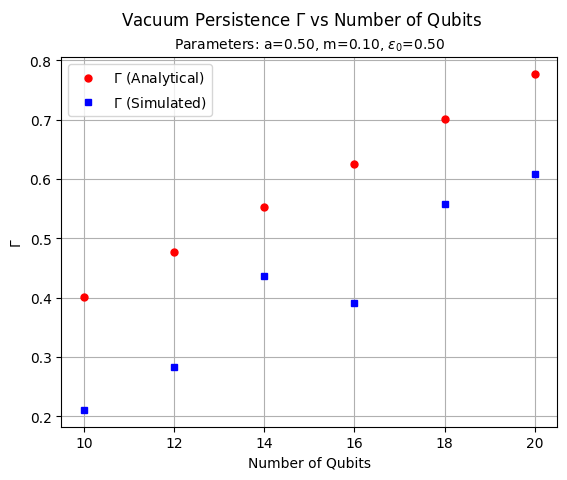

In [3]:
analysis_name = f"decay_rate_qubits_num"
file_name     = f"decay_rate_qubits_num"

# Get values of L
min_qubit_num, max_qubit_num = 10, 20
step = 2
qubit_num_values = np.arange(min_qubit_num, max_qubit_num+step, step)

# Get needed data for each L
analysis_name = "qubits_num_quench"
qubits_num_data = load_evolution_and_initial(analysis_name, qubit_num_values,
                                         evolution_temp="qubits_num_{value}_quench_data.csv",
                                         initial_state_temp="qubits_num_{value}_initial_state.qpy",
                                         backup_config=config,
                                         backup_key="L",
                                         use_simulated_data=USE_SIMULATED_DATA)

# Get results
fit_results_df = fit_persistence_qubits_num(config, qubit_num_values, qubits_num_data)
plot_params = parseDictToPlot(
    {**config["Hamiltonian"]["Parameters"], **config["Temporal Evolution"]["Quench"]["Parameters_to_Change"]},
    remove_keys=["L"],
    rename_keys={"e0": "$\\varepsilon_0$"})
fig, ax = plot_gamma_vs_qubitNum(fit_results_df, params=plot_params)

# Calculate deviation to find best fit
fit_results_df["Deviation"] = np.abs(1 - fit_results_df["Gamma_Analytical"]/ fit_results_df["Gamma_Simulated"])
best_qubit_num = int(fit_results_df["Deviation"].idxmin())

plt.show()

## 2. Show best fit

Once we have the best qubit number on the cell above (the one with the lowest deviation between the analytical and simulated value), we focus on it studying the quench dynamics, how the vacuum persistence probability decays over time.

We implement a custom 1st/2nd derivative cutoff algorithm to strictly isolate the pure exponential decay regime. This systematically removes:
1. Early-time artifacts (Quantum Zeno effect).
2. Late-time artifacts (Finite-size boundary revivals).

On the exponential regime, we have plotted the results of the simulation and the Schwinger prediction, which is computed by:

$$\Gamma = \int dx \ \gamma(x), \ \gamma(x) = \frac{E(x)}{2\pi} \exp\left(-\frac{\pi m^2}{E(x)}\right),$$

with the lattice version calculated as

$$\Gamma \approx \sum_n^L a \gamma_n = \sum_n^L a \gamma (E_n),$$

where $E_n$ is the electric field in the site $n$, $E_n = \varepsilon_0 + \sum_{k=0}^n q_k$.

2026-04-20 16:16:24 INFO: Parameters of the hamiltonian to check regime:
    w = 1.00  (hopping)
    J = 0.2500  (gauge coupling)
    w/J = 4.0  (must be O(1) for non trivial physics)
    eE/πm² = 15.92  (must be >> 1)
    L_phys·M_S = 4.80  (must be >> 1)
    eE·a = 0.250  (must be << 1 for continous limit)
2026-04-20 16:16:24 INFO: Γ (simulated):  0.5576 ± 0.0197
2026-04-20 16:16:24 INFO: Γ (analytical): 0.7002
2026-04-20 16:16:24 INFO: Deviation: 20.4%
2026-04-20 16:16:24 INFO: log-linear slope: 0.4519
2026-04-20 16:16:24 INFO: R² of linear fit: 0.9360


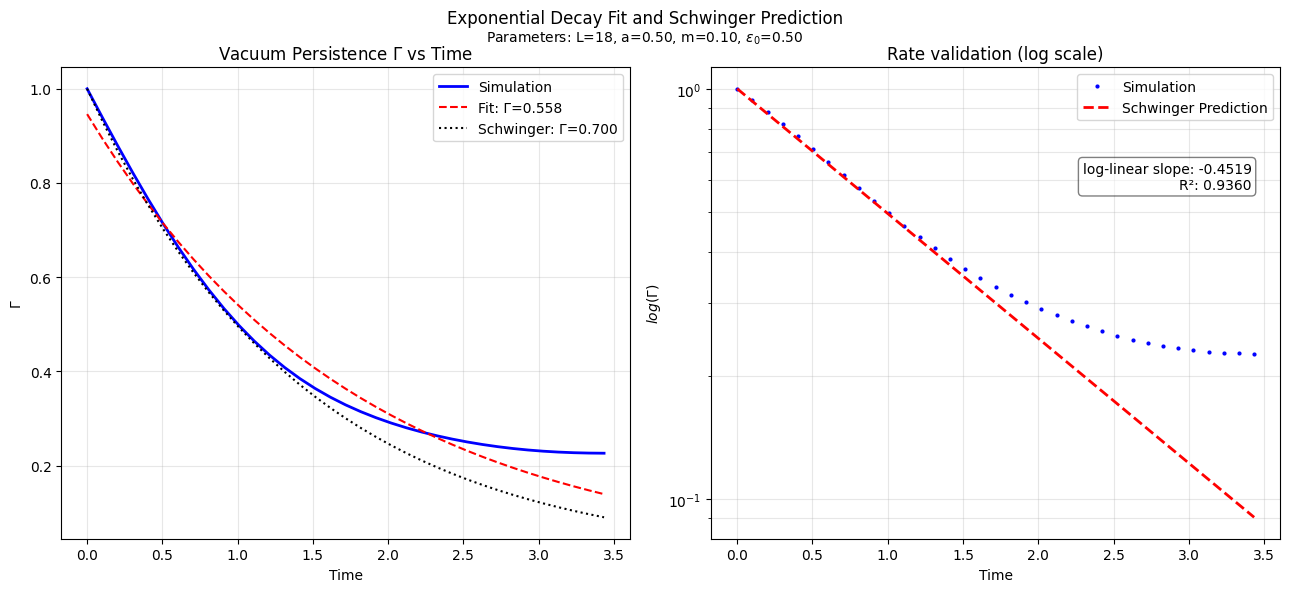

In [4]:
analysis_name = f"best_{best_qubit_num}_decay_rate"
file_name     = f"best_{best_qubit_num}_decay_rate"

# Get evolution data and initial state for best simulation
evolution_data = qubits_num_data[best_qubit_num]["evolution_data"]
initial_state  = qubits_num_data[best_qubit_num]["initial_state"]
# Use config from best simulation
qubits_num_config = copy.deepcopy(config)
qubits_num_config["QubitsNumber"] = best_qubit_num
qubits_num_config["Hamiltonian"]["Parameters"]["L"] = best_qubit_num

# Fit persistence to get plot showing exponential fit
fig, axes = fit_persistence(
    evolution_data, qubits_num_config, initial_state,
    use_offset=False,
    return_plot=True
)
# Show fig
plt.show()

## 3. Plot persistence and regimes for best fit

For the best fit, the full evolution of vacuum persistence is plotted, with the different regimes outlined.

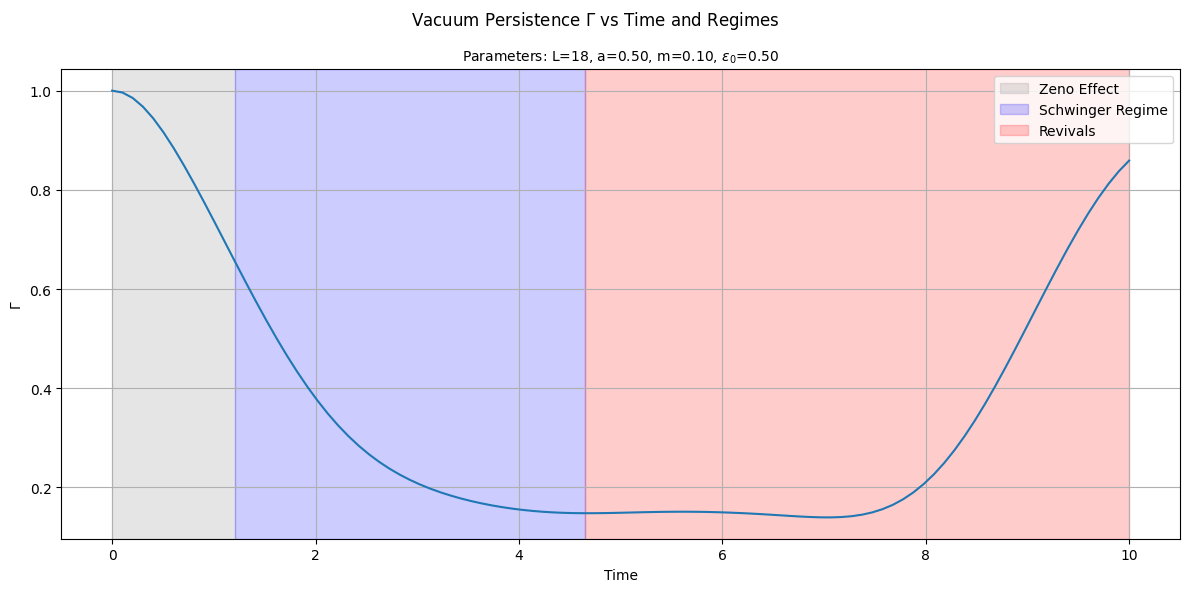

In [5]:
analysis_name = f"best_{best_qubit_num}_persistenece_vs_time"
file_name     = f"best_{best_qubit_num}_persistenece_vs_time"
# Use evoltion data and cut off times to plot persistence vs time with different regimes
cut_off_times = fit_results_df.loc[best_qubit_num, "Cut_Off_Times"]
plot_params = parseDictToPlot(
    {**qubits_num_config["Hamiltonian"]["Parameters"], **qubits_num_config["Temporal Evolution"]["Quench"]["Parameters_to_Change"]},
    remove_keys=[],
    rename_keys={"e0": "$\\varepsilon_0$"})
fig, ax = plot_persistenece_vs_time_regimes(evolution_data, cut_off_times, plot_params)
# Show fig
plt.show()

## 4. Show best fit for different values of $\varepsilon_0$

We analyze how the vaccum persistence varies for different values of $\varepsilon_0$.

The background field is related to the topological angle of vacuum $\theta$ as $\varepsilon_0 = \frac{\theta}{2\pi}$. We see that the figure shows an "elbow" near $\varepsilon_0 = 0.54$, which can be regarded as a phase transition, that is expected to be at $\theta=\pi$ ($\varepsilon_0 = 0.5$). For higher values of $\varepsilon_0$, the Schwinger formula is not valid anymore.

2026-04-20 16:16:27 INFO: Running simulation for value=0.4 with backup config.

######################################################################
2026-04-20 16:16:27 INFO: Initializing SchwingerSimulation class.
2026-04-20 16:16:27 INFO: No backend specified, state is going to evolve with direct matrix gates multiplication.
2026-04-20 16:16:27 INFO: Starting simulation.
2026-04-20 16:16:27 INFO: Parameters of the hamiltonian: {'L': 18, 'a': 0.5, 'm': 0.1, 'e0': 0}
2026-04-20 16:16:27 INFO: Norm of the conmutator: [H, Q] = 0.00e+00
2026-04-20 16:16:27 INFO: Hamiltonian respects charge symmetry.
2026-04-20 16:16:29 INFO: Initial energy = -20.309350085424747
2026-04-20 16:16:30 INFO: Initial charge = -2.1371793224034263e-15
2026-04-20 16:16:30 INFO: Evolution gate type Pauli with synthesis method TrotterSuzuki selected. Synthesis parameters: {'order': 2}
2026-04-20 16:16:30 INFO: Applying Quench with parameters: {'e0': 0.4}


Evolving state:   0%|          | 0/100 [00:00<?, ?step/s]

2026-04-20 16:18:32 INFO: Simulation ended.
######################################################################

2026-04-20 16:18:32 INFO: Simulation for value=0.4 took 125.23 seconds.
2026-04-20 16:18:32 INFO: Running simulation for value=0.42000000000000004 with backup config.

######################################################################
2026-04-20 16:18:32 INFO: Initializing SchwingerSimulation class.
2026-04-20 16:18:32 INFO: No backend specified, state is going to evolve with direct matrix gates multiplication.
2026-04-20 16:18:32 INFO: Starting simulation.
2026-04-20 16:18:32 INFO: Parameters of the hamiltonian: {'L': 18, 'a': 0.5, 'm': 0.1, 'e0': 0}
2026-04-20 16:18:32 INFO: Norm of the conmutator: [H, Q] = 0.00e+00
2026-04-20 16:18:32 INFO: Hamiltonian respects charge symmetry.
2026-04-20 16:18:34 INFO: Initial energy = -20.309350085424747
2026-04-20 16:18:35 INFO: Initial charge = -2.1371793224034263e-15
2026-04-20 16:18:35 INFO: Evolution gate type Pauli with syn

Evolving state:   0%|          | 0/100 [00:00<?, ?step/s]

2026-04-20 16:20:51 INFO: Simulation ended.
######################################################################

2026-04-20 16:20:51 INFO: Simulation for value=0.42000000000000004 took 138.55 seconds.
2026-04-20 16:20:51 INFO: Running simulation for value=0.44000000000000006 with backup config.

######################################################################
2026-04-20 16:20:51 INFO: Initializing SchwingerSimulation class.
2026-04-20 16:20:51 INFO: No backend specified, state is going to evolve with direct matrix gates multiplication.
2026-04-20 16:20:51 INFO: Starting simulation.
2026-04-20 16:20:51 INFO: Parameters of the hamiltonian: {'L': 18, 'a': 0.5, 'm': 0.1, 'e0': 0}
2026-04-20 16:20:51 INFO: Norm of the conmutator: [H, Q] = 0.00e+00
2026-04-20 16:20:51 INFO: Hamiltonian respects charge symmetry.
2026-04-20 16:20:52 INFO: Initial energy = -20.309350085424747
2026-04-20 16:20:54 INFO: Initial charge = -2.1371793224034263e-15
2026-04-20 16:20:54 INFO: Evolution gate typ

...

2026-04-20 17:29:03 INFO: Simulation ended.
######################################################################

2026-04-20 17:29:03 INFO: Simulation for value=1.4000000000000004 took 129.51 seconds.
2026-04-20 17:29:03 INFO: Running simulation for value=1.5000000000000004 with backup config.

######################################################################
2026-04-20 17:29:03 INFO: Initializing SchwingerSimulation class.
2026-04-20 17:29:03 INFO: No backend specified, state is going to evolve with direct matrix gates multiplication.
2026-04-20 17:29:03 INFO: Starting simulation.
2026-04-20 17:29:03 INFO: Parameters of the hamiltonian: {'L': 18, 'a': 0.5, 'm': 0.1, 'e0': 0}
2026-04-20 17:29:03 INFO: Norm of the conmutator: [H, Q] = 0.00e+00
2026-04-20 17:29:03 INFO: Hamiltonian respects charge symmetry.
2026-04-20 17:29:04 INFO: Initial energy = -20.309350085424747
2026-04-20 17:29:05 INFO: Initial charge = -2.1371793224034263e-15
2026-04-20 17:29:05 INFO: Evolution gate type 

Evolving state:   0%|          | 0/100 [00:00<?, ?step/s]

2026-04-20 17:31:12 INFO: Simulation ended.
######################################################################

2026-04-20 17:31:12 INFO: Simulation for value=1.5000000000000004 took 129.27 seconds.
2026-04-20 17:31:12 INFO: Running simulation for value=1.6000000000000005 with backup config.

######################################################################
2026-04-20 17:31:12 INFO: Initializing SchwingerSimulation class.
2026-04-20 17:31:12 INFO: No backend specified, state is going to evolve with direct matrix gates multiplication.
2026-04-20 17:31:12 INFO: Starting simulation.
2026-04-20 17:31:12 INFO: Parameters of the hamiltonian: {'L': 18, 'a': 0.5, 'm': 0.1, 'e0': 0}
2026-04-20 17:31:12 INFO: Norm of the conmutator: [H, Q] = 0.00e+00
2026-04-20 17:31:12 INFO: Hamiltonian respects charge symmetry.
2026-04-20 17:31:14 INFO: Initial energy = -20.309350085424747
2026-04-20 17:31:15 INFO: Initial charge = -2.1371793224034263e-15
2026-04-20 17:31:15 INFO: Evolution gate type 

Evolving state:   0%|          | 0/100 [00:00<?, ?step/s]

2026-04-20 17:33:14 INFO: Simulation ended.
######################################################################

2026-04-20 17:33:14 INFO: Simulation for value=1.6000000000000005 took 122.10 seconds.


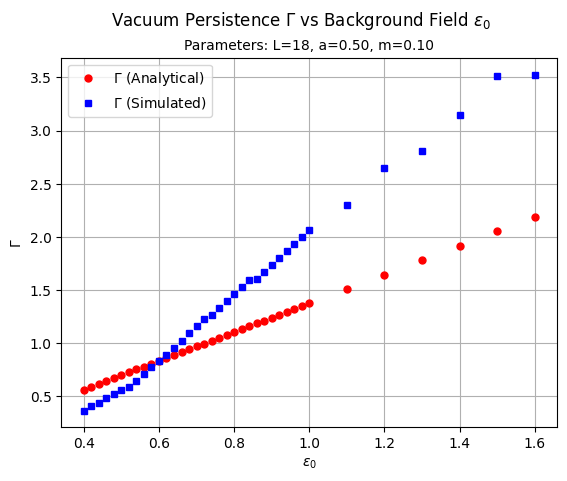

In [6]:
# Take best simulation
qubits_num = best_qubit_num

analysis_name = f"e0_quench_{qubits_num}qubits"
file_name     = f"e0_quench_{qubits_num}qubits"

# Define e0 values to show Gamma
min_e0, max_e0 = 0.4, 0.98
step = 0.02
e0_values = np.arange(min_e0, max_e0+step, step)

min_e0_2, max_e0_2 = 1.0, 1.5
step2 = 0.1
e0_values = np.concatenate((e0_values, np.arange(min_e0_2, max_e0_2+step2, step2)))

# Initial state for simulation (in case data is not found)
# Can get from previous simulation, it's the same for all e0 since e0 is quenched
try:    initial_state = qubits_num_data[qubits_num]["initial_state"]
except: initial_state = None

e0_data = load_evolution_and_initial(analysis_name, e0_values,
                                evolution_temp="e0_{value}_quench_data.csv",
                                initial_state_temp="e0_{value}_initial_state.qpy",
                                backup_config=qubits_num_config,
                                backup_initial_state=initial_state,
                                backup_key="e0",
                                backup_key_is_quench=True,
                                use_simulated_data=USE_SIMULATED_DATA)

# Get results of gamma(e0)
fit_results_df = fit_persistence_e0(qubits_num_config, e0_values, e0_data)

# Plot gamma(e0)
plot_params = parseDictToPlot(
    qubits_num_config["Hamiltonian"]["Parameters"],
    remove_keys=["e0"],
    rename_keys={})
fig, ax = plot_gamma_vs_e0(fit_results_df, params=plot_params)
# Show fig
plt.show()

## 5. Plot $\log\left(\frac{\Gamma}{\varepsilon_0}\right)$ vs $\frac{1}{\varepsilon_0}$ for Schwinger regime

The analytical Schwinger formula predicts a non-perturbative, tunneling-like decay rate:
$$\Gamma \propto E \exp\left(-\frac{\pi m_{\text{eff}}^2}{E}\right)$$

If the quantum simulation successfully captures this non-perturbative regime, plotting $\ln(\Gamma / \langle E_n \rangle)$ against $1 / \langle E_n \rangle$ will yield a **straight line**. 
Furthermore, the slope of this line is directly proportional to $-\pi m_{\text{eff}}^2$, allowing us to extract the **dressed (renormalized) mass** of the particles generated dynamically by the lattice interactions.

We use the measured physical electric field $\langle E_n \rangle$ (dynamically generated by the state) rather than the bare parameter $\varepsilon_0$ to account for vacuum polarization.

The linear regression perfectly captures the tunneling signature. From the slope, we extract an effective dressed mass of **$m_{\text{eff}} \approx 0.407$**. 

Due to lattice interactions and vacuum polarization, the "bare" mass parameter ($m_{\text{bare}} = 0.1$) fed into the Hamiltonian is dynamically renormalized. The simulated particles are significantly heavier than their bare parameters suggest.

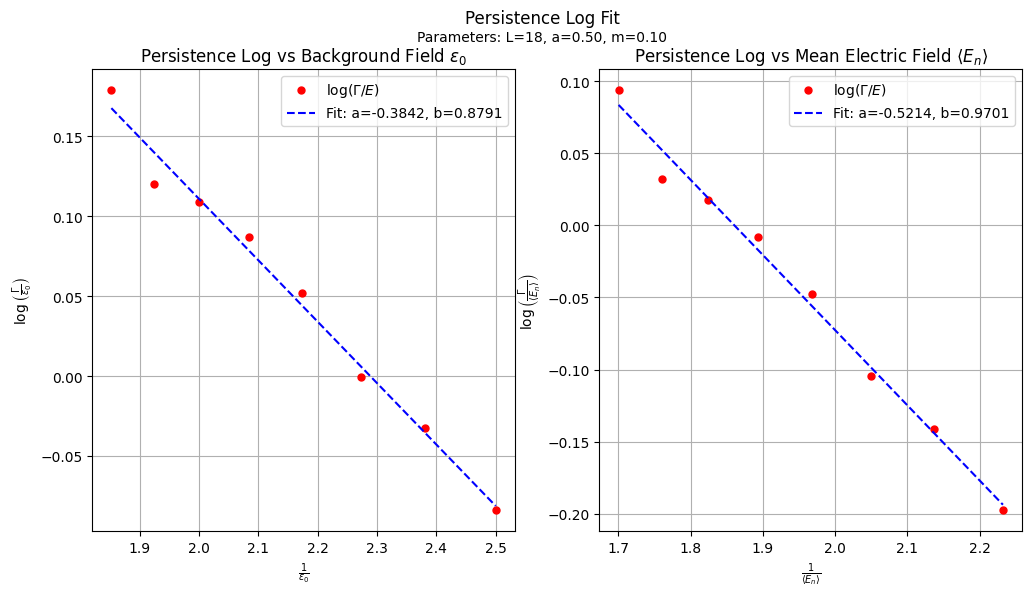

In [7]:
analysis_name = f"best_{qubits_num}_logPersistenece_vs_electricField"
file_name     = f"best_{qubits_num}_logPersistenece_vs_electricField"
min_e0, max_e0 = 0.4, 0.541 # Found by inspection

# Take e0 values from previous fit results
e0_values = fit_results_df.index.values
e0_values = e0_values[(e0_values >= min_e0) & (e0_values <= max_e0)]
fit_reg_results_df = fit_results_df.loc[e0_values]

# Values of gamma
gamma_simulated = fit_reg_results_df["Gamma_Simulated"].values
# Values of physical field
field_values = fit_reg_results_df["E_Physical"].apply(lambda x: np.mean(x)).values

# Plot log Gamma/e0 vs 1/e0 for Schwinger regime
plot_params = parseDictToPlot(
    qubits_num_config["Hamiltonian"]["Parameters"],
    remove_keys=["e0"],
    rename_keys={})
fig, axes, fit_params = plot_gamma_vs_electricField(gamma_simulated, e0_values, field_values, plot_params)
# Show fig
plt.show()